# Предобработка и очистка датасета `ecom_yl_new.csv`

В этом notebook оставлены только шаги, связанные с очисткой и подготовкой данных:

- загрузка датасета;
- приведение названий столбцов к PEP8;
- преобразование типов;
- обработка пропусков;
- исправление неявных дубликатов в категориях и по ключу сессии;
- проверка логических аномалий;
- удаление полных дубликатов;
- при необходимости заполнение пропусков в `hour_of_day`, `month`, `day` медианой;
- сглаживание выбросов по IQR для `session_duration_sec` и `revenue` (медиана);
- создание новых признаков `payer`, `session_duration_sec`, `final_revenue`, `time_of_day`;
- сохранение очищенного датасета.


In [728]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

## 1. Загрузка данных

Файл читается с разделителем `;`, так как исходный CSV сохранён именно в таком формате.

In [729]:
df = pd.read_csv("ecom_yl_new.csv", sep=";")
df.head()

,User Id,Region,Device,Channel,Session Start,Session End,SessionDurationSec,Session Date,Month,Day,Hour of day,Order Dt,Revenue,Payment Type,Promo code
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0,2025-05-01,5,3,0,2025-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.0,2025-05-01,5,3,7,NaN,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.0,2025-05-01,5,3,4,NaN,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.0,2025-05-01,5,3,18,NaN,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.0,2025-05-02,5,4,14,NaN,NaN,NaN,NaN


## 2. Приведение названий столбцов к PEP8

Названия столбцов:
- очищаются от лишних пробелов;
- переводятся в нижний регистр;
- пробелы заменяются на `_`.

In [730]:
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', "_", regex=True)

if 'sessiondurationsec' in df.columns:
    df = df.rename(columns={'sessiondurationsec': 'sessiondurationsec'})

df.columns.tolist()

['user_id',
 'region',
 'device',
 'channel',
 'session_start',
 'session_end',
 'sessiondurationsec',
 'session_date',
 'month',
 'day',
 'hour_of_day',
 'order_dt',
 'revenue',
 'payment_type',
 'promo_code']

## 3. Преобразование дат и числовых столбцов

Столбцы с датой переводятся в формат `datetime`, а числовые поля — в `numeric`.

In [731]:
date_columns = ['session_start', 'session_end', 'session_date', 'order_dt']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

numeric_columns = ['sessiondurationsec', 'hour_of_day', 'revenue', 'promo_code', 'month', 'day']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             1012 non-null   int64         
 1   region              999 non-null    object        
 2   device              999 non-null    object        
 3   channel             999 non-null    object        
 4   session_start       1012 non-null   datetime64[ns]
 5   session_end         1012 non-null   datetime64[ns]
 6   sessiondurationsec  1012 non-null   float64       
 7   session_date        1012 non-null   datetime64[ns]
 8   month               1012 non-null   int64         
 9   day                 1012 non-null   int64         
 10  hour_of_day         1012 non-null   int64         
 11  order_dt            285 non-null    datetime64[ns]
 12  revenue             285 non-null    float64       
 13  payment_type        285 non-null    object      

## 4. Проверка пропусков

Пропуски в `region`, `device`, `channel` считаются критичными для анализа, поэтому такие строки удаляются.

Пропуски в `order_dt`, `revenue`, `payment_type`, `promo_code` логически связаны с отсутствием покупки и не считаются ошибкой данных.

In [732]:
missing_before = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().sum() / len(df) * 100).round(2)
})

missing_before.sort_values('missing_count', ascending=False)

,missing_count,missing_percent
revenue,727,71.84
payment_type,727,71.84
promo_code,727,71.84
order_dt,727,71.84
region,13,1.28
device,13,1.28
channel,13,1.28
sessiondurationsec,0,0.00
session_end,0,0.00
session_start,0,0.00


In [733]:
df = df.dropna(subset=['region', 'device', 'channel']).copy()
df.shape

(999, 15)

## 5. Создание признака `payer`

Если в строке есть дата покупки `order_dt`, считаем пользователя платящим (`1`), иначе — неплатящим (`0`).

In [734]:
df['payer'] = df['order_dt'].notna().astype(int)
df['payer'].value_counts()

,count
payer,
0,722
1,277


## 6. Нормализация категориальных признаков

Для `region`, `channel`, `device`, `payment_type`:
- убираются лишние пробелы;
- значения переводятся в нижний регистр;
- исправляются опечатки и неявные дубликаты.

In [735]:
df['region'] = df['region'].astype(str).str.strip().str.lower()
df['channel'] = df['channel'].astype(str).str.strip().str.lower()
df['device'] = df['device'].astype(str).str.strip().str.lower()
df['payment_type'] = df['payment_type'].astype(str).str.strip().str.lower()
df['payment_type'] = df['payment_type'].replace('nan', np.nan)

In [736]:
df['region'] = df['region'].replace({
    'franсe': 'france',
    'frаnce': 'france',
    'frаncе': 'france',
    'unjted states': 'united states',
    'uк': 'uk'
})

df['channel'] = df['channel'].replace({
    'контексная реклама': 'контекстная реклама'
})

print(sorted(df['region'].dropna().unique()))
print(sorted(df['channel'].dropna().unique()))
print(sorted(df['device'].dropna().unique()))

['france', 'germany', 'uk', 'united states']
['email-рассылки', 'organic', 'контекстная реклама', 'реклама у блогеров', 'социальные сети']
['android', 'iphone', 'mac', 'pc']


## 7. Пересчёт длительности сессии

Вместо исходного столбца длительность сессии пересчитывается по разнице между `session_end` и `session_start`.

In [737]:
df['session_duration_sec'] = (df['session_end'] - df['session_start']).dt.total_seconds()
df[['session_start', 'session_end', 'session_duration_sec']].head()

,session_start,session_end,session_duration_sec
0,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0
1,2025-05-01 06:56:16,2025-05-01 07:09:18,782.0
2,2025-05-01 04:30:45,2025-05-01 04:34:56,251.0
3,2025-05-01 18:53:42,2025-05-01 18:57:35,233.0
4,2025-05-02 14:04:32,2025-05-02 14:09:51,319.0


## 8. Проверка логических аномалий

Проверяем:
- диапазон дат визитов;
- отрицательную длительность;
- отрицательную выручку;
- часы вне диапазона `0–23`;
- случаи, где дата покупки раньше начала сессии.

In [738]:
print("Минимальная дата визита:", df['session_date'].min())
print("Максимальная дата визита:", df['session_date'].max())
print()
print("Отрицательная длительность сессии:", (df['session_duration_sec'] < 0).sum())
print("Отрицательная выручка:", (df['revenue'] < 0).sum())
print("Часы вне диапазона 0-23:", ((df['hour_of_day'] < 0) | (df['hour_of_day'] > 23)).sum())
print("session_end раньше session_start:", (df['session_end'] < df['session_start']).sum())
print("order_dt раньше session_start:", (df['order_dt'] < df['session_start']).sum())

Минимальная дата визита: 2025-05-01 00:00:00
Максимальная дата визита: 2025-10-31 00:00:00

Отрицательная длительность сессии: 0
Отрицательная выручка: 0
Часы вне диапазона 0-23: 0
session_end раньше session_start: 0
order_dt раньше session_start: 1


In [739]:
bad_order_rows = df[df['order_dt'] < df['session_start']]
bad_order_rows

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,payer,session_duration_sec
287,324558127766,united states,android,социальные сети,2025-06-28 00:39:02,2025-06-28 02:34:25,6923.0,2025-06-28,6,5,2,2025-06-26 07:23:59,4999.0,e-wallet,1.0,1,6923.0


## 9. Удаление логически некорректных строк

Если `order_dt < session_start`, такая строка противоречит логике одной пользовательской сессии и удаляется.

In [740]:
df = df[df['order_dt'].isna() | (df['order_dt'] >= df['session_start'])].copy()
df.shape

(998, 17)

## 10. Удаление лишнего исходного столбца с длительностью

После пересчёта удаляем исходный `sessiondurationsec`, чтобы не хранить дублирующую информацию.

In [741]:
if 'sessiondurationsec' in df.columns:
    df = df.drop(columns=['sessiondurationsec']).copy()

df.columns.tolist()

['user_id',
 'region',
 'device',
 'channel',
 'session_start',
 'session_end',
 'session_date',
 'month',
 'day',
 'hour_of_day',
 'order_dt',
 'revenue',
 'payment_type',
 'promo_code',
 'payer',
 'session_duration_sec']

## 10a. Неявные дубликаты по ключу сессии

Строки, у которых совпадают `user_id`, `session_start` и `session_end`, считаются одной и той же сессией: отличаются могут отдельные поля (выручка, промокод, тип оплаты и т.д.). Для анализа оставляем первую запись (`keep='first'`).

In [742]:
implicit_dup_cols = ['user_id', 'session_start', 'session_end']
print('Строк в группах неявных дубликатов:', df.duplicated(subset=implicit_dup_cols, keep=False).sum())
df = df.drop_duplicates(subset=implicit_dup_cols, keep='first').copy()
print('Размер после удаления неявных дубликатов:', df.shape)

Строк в группах неявных дубликатов: 4
Размер после удаления неявных дубликатов: (996, 16)


## 11. Удаление полных дубликатов

Полные дубликаты — это полностью совпадающие строки, которые могут исказить результаты анализа.

In [743]:
print("Количество полных дубликатов:", df.duplicated().sum())

Количество полных дубликатов: 0


In [744]:
df = df.drop_duplicates().copy()
print("Размер датасета после удаления полных дубликатов:", df.shape)

Размер датасета после удаления полных дубликатов: (996, 16)


## 11a. Пропуски в «нейтральных» числовых признаках

Пропуски в `hour_of_day`, `month`, `day` не связаны с фактом покупки, поэтому при появлении таких пропусков их можно заполнить медианой по столбцу (как альтернатива удалению строк). Пропуски в `revenue` и `order_dt` по-прежнему означают отсутствие покупки — их не заполняем.

## 11b. Выбросы (правило IQR) и замена на медиану

Для `session_duration_sec` и для ненулевой выручки `revenue` выбросы определяются по межквартильному размаху: значения ниже `Q1 - 1.5 * IQR` или выше `Q3 + 1.5 * IQR`. Такие значения заменяются медианой по «невыбросным» наблюдениям в том же столбце, чтобы не раздувать суммы и не терять строки. Перед расчётом `final_revenue` выручка уже приведена к более устойчивому виду.

In [745]:
for _col in ('hour_of_day', 'month', 'day'):
    if df[_col].isna().any():
        df[_col] = df[_col].fillna(df[_col].median())

if df['session_duration_sec'].isna().any():
    df['session_duration_sec'] = df['session_duration_sec'].fillna(
        df['session_duration_sec'].median()
    )


def _iqr_outlier_mask(series):
    s = series.dropna()
    if len(s) < 4:
        return pd.Series(False, index=series.index)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(False, index=series.index)
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < low) | (series > high)


outliers_duration = _iqr_outlier_mask(df['session_duration_sec'])
print('Выбросы по длительности сессии (IQR):', outliers_duration.sum())

if outliers_duration.any():
    med_dur = df.loc[~outliers_duration, 'session_duration_sec'].median()
    if pd.isna(med_dur):
        med_dur = df['session_duration_sec'].median()
    df.loc[outliers_duration, 'session_duration_sec'] = med_dur

outliers_revenue = _iqr_outlier_mask(df['revenue']) & df['revenue'].notna()
print('Выбросы по revenue среди покупок (IQR):', outliers_revenue.sum())

if outliers_revenue.any():
    med_rev = df.loc[df['revenue'].notna() & ~outliers_revenue, 'revenue'].median()
    if pd.isna(med_rev):
        med_rev = df['revenue'].median()
    df.loc[outliers_revenue, 'revenue'] = med_rev

Выбросы по длительности сессии (IQR): 52
Выбросы по revenue среди покупок (IQR): 24


## 12. Проверка пропусков после очистки

На этом этапе смотрим, какие пропуски остались в данных.

In [746]:
missing_after = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().sum() / len(df) * 100).round(2)
})

missing_after.sort_values('missing_count', ascending=False)

,missing_count,missing_percent
payment_type,722,72.49
promo_code,722,72.49
order_dt,722,72.49
revenue,722,72.49
user_id,0,0.00
region,0,0.00
device,0,0.00
channel,0,0.00
month,0,0.00
session_date,0,0.00


## 13. Создание столбца `final_revenue`

Если `promo_code = 1`, к сумме покупки применяется скидка 10%.
Если `promo_code = 0`, сумма покупки не меняется.
Если покупки не было, значение остаётся пустым.

In [747]:
df['final_revenue'] = np.where(
    df['revenue'].notna(),
    np.where(df['promo_code'].fillna(0) == 1, df['revenue'] * 0.9, df['revenue']),
    np.nan
)

df[['revenue', 'promo_code', 'final_revenue']].head(10)

,revenue,promo_code,final_revenue
0,4999.0,0.0,4999.0
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


## 14. Создание столбца `time_of_day`

Время суток определяется по часу визита:
- `06:00–09:59` — `morning`
- `10:00–16:59` — `day`
- `17:00–21:59` — `evening`
- `22:00–05:59` — `night`

In [748]:
def get_time_of_day(hour):
    if pd.isna(hour):
        return np.nan
    if 6 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 16:
        return 'day'
    elif 17 <= hour <= 21:
        return 'evening'
    else:
        return 'night'

df['time_of_day'] = df['hour_of_day'].apply(get_time_of_day)
df[['hour_of_day', 'time_of_day']].head(10)

,hour_of_day,time_of_day
0,0,night
1,7,morning
2,4,night
3,18,evening
4,14,day
5,8,morning
6,16,day
7,10,day
8,19,evening
9,20,evening


## 15. Финальная проверка типов и структуры

Проверяем размер очищенного датасета, уникальные значения ключевых категорий и оставшиеся пропуски.

In [749]:
print('Размер очищенного датасета:', df.shape)
print('\nУникальные значения region:')
print(sorted(df['region'].dropna().unique()))
print('\nУникальные значения channel:')
print(sorted(df['channel'].dropna().unique()))
print('\nУникальные значения promo_code:')
print(df['promo_code'].value_counts(dropna=False))
print('\nПропуски после очистки:')
print(df.isna().sum())
print('\nПериод исследования:')
print('Начало:', df['session_date'].min())
print('Конец:', df['session_date'].max())

Размер очищенного датасета: (996, 18)

Уникальные значения region:
['france', 'germany', 'uk', 'united states']

Уникальные значения channel:
['email-рассылки', 'organic', 'контекстная реклама', 'реклама у блогеров', 'социальные сети']

Уникальные значения promo_code:
promo_code
NaN         722
0.000000    196
1.000000     76
0.862715      2
Name: count, dtype: int64

Пропуски после очистки:
user_id                   0
region                    0
device                    0
channel                   0
session_start             0
session_end               0
session_date              0
month                     0
day                       0
hour_of_day               0
order_dt                722
revenue                 722
payment_type            722
promo_code              722
payer                     0
session_duration_sec      0
final_revenue           722
time_of_day               0
dtype: int64

Период исследования:
Начало: 2025-05-01 00:00:00
Конец: 2025-10-31 00:00:00


## 16. Сохранение очищенного датасета

In [750]:
df.to_csv("ecom_yl_cleaned.csv", sep=";", index=False, encoding="utf-8-sig")

## 17. Краткий итог

В ходе предобработки были выполнены следующие шаги:

- загружен исходный датасет;
- названия столбцов приведены к формату PEP8;
- даты и числовые признаки преобразованы в корректные типы;
- удалены строки с критичными пропусками в `region`, `device`, `channel`;
- создан признак `payer`;
- исправлены неявные дубликаты в категориальных признаках;
- пересчитана длительность сессии;
- удалена логически некорректная строка, где покупка была раньше начала сессии;
- удалены неявные дубликаты по ключу `user_id` + `session_start` + `session_end`;
- удалены полные дубликаты;
- при наличии пропусков в `hour_of_day`, `month`, `day` они заполнены медианой;
- выбросы по IQR в `session_duration_sec` и `revenue` заменены медианой по невыбросным значениям;
- создан столбец `final_revenue` с учётом промокода;
- создан столбец `time_of_day`;
- сохранён очищенный датасет `ecom_yl_cleaned.csv`.

# Аналитический и графический анализ данных


## 1. Доля продаж по регионам:

,region,share
3,united states,0.698846
2,uk,0.119459
0,france,0.093390
1,germany,0.088305


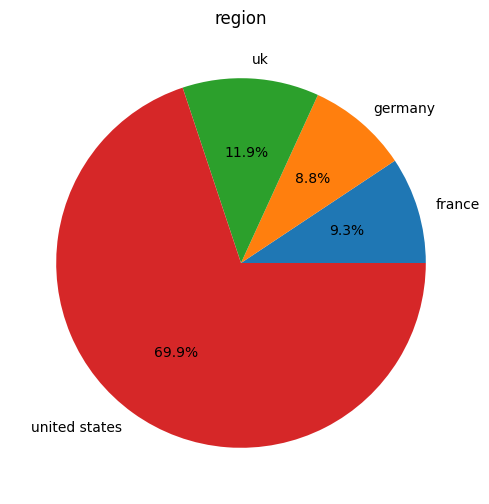

In [751]:
df_sales_region = df.groupby('region')['final_revenue'].sum()
df_share_region = df_sales_region / df_sales_region.sum()

df_share_region = df_share_region.reset_index()
df_share_region.columns = ['region', 'share']
display(df_share_region.sort_values(by='share', ascending=False))

labels = df_share_region['region']
df_share_region['share'].plot(
    kind='pie',
    labels=labels,
    autopct='%1.1f%%',
    figsize=(6, 6)
  )
plt.title('region')
plt.ylabel('')
plt.show()

## Больше всего продаж совершается в США - `69.9%`

## 2. Доля продаж по источникам:

,channel,share
4,социальные сети,0.401704
1,organic,0.316121
2,контекстная реклама,0.150899
3,реклама у блогеров,0.108358
0,email-рассылки,0.022918


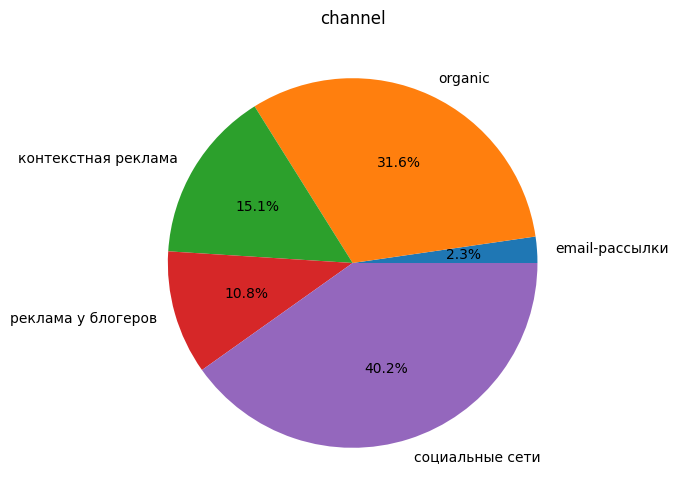

In [752]:
df_sales_channel = df.groupby('channel')['final_revenue'].sum()
df_share_channel = df_sales_channel / df_sales_channel.sum()

df_share_channel = df_share_channel.reset_index()
df_share_channel.columns = ['channel', 'share']
display(df_share_channel.sort_values(by='share', ascending=False))

labels = df_share_channel['channel']
df_share_channel['share'].plot(
    kind='pie',
    labels=labels,
    autopct='%1.1f%%',
    figsize=(6, 6)
  )
plt.title('channel')
plt.ylabel('')
plt.show()


## Самые популярный рекламный канал - социальные сети `40.2%`
## Также много пользователей(`31.6%`) переходят на сайт самостоятельно, без затрат на рекламу

## 3. Доля продаж по устройствам:

,device,share
1,iphone,0.342118
0,android,0.258183
2,mac,0.214424
3,pc,0.185275


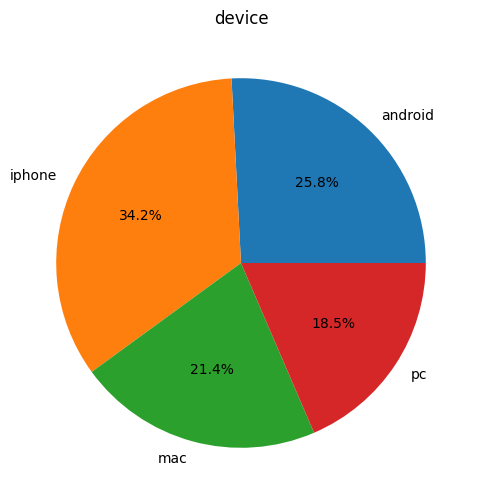

In [753]:
df_sales_device = df.groupby('device')['final_revenue'].sum()
df_share_device = df_sales_device / df_sales_device.sum()

df_share_device = df_share_device.reset_index()
df_share_device.columns = ['device', 'share']
display(df_share_device.sort_values(by='share', ascending=False))

labels = df_share_device['device']
df_share_device['share'].plot(
    kind='pie',
    labels=labels,
    autopct='%1.1f%%',
    figsize=(6, 6)
  )
plt.title('device')
plt.ylabel('')
plt.show()
print('\n\n')

## Большая часть пользователей(`34.2%`) заходят на сайт с айфона


## 4. Количество пользователей с разбивкой на платящих/не платящих по регионам:

payer,0,1
region,,
france,78,25
germany,78,24
uk,83,32
united states,483,193


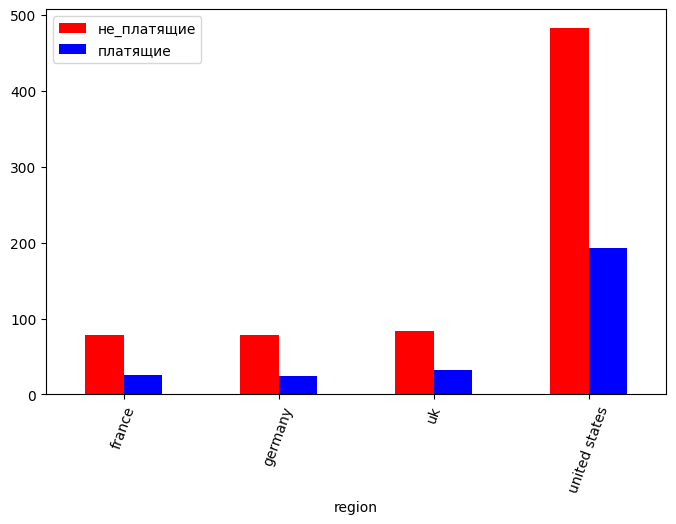

In [754]:
df_counts_region = df.groupby(['region', 'payer']).size().unstack(fill_value=0)
display(df_counts_region)

df_counts_region.plot(
    kind='bar',
    stacked=False,
    figsize=(8, 5),
    color=['red', 'blue']
  )
plt.xticks(rotation=70)
plt.legend(['не_платящие', 'платящие'])
plt.show()

## 5. Количество пользователей с разбивкой на платящих/не платящих по устройствам:

payer,0,1
device,,
android,164,70
iphone,261,94
mac,142,59
pc,155,51


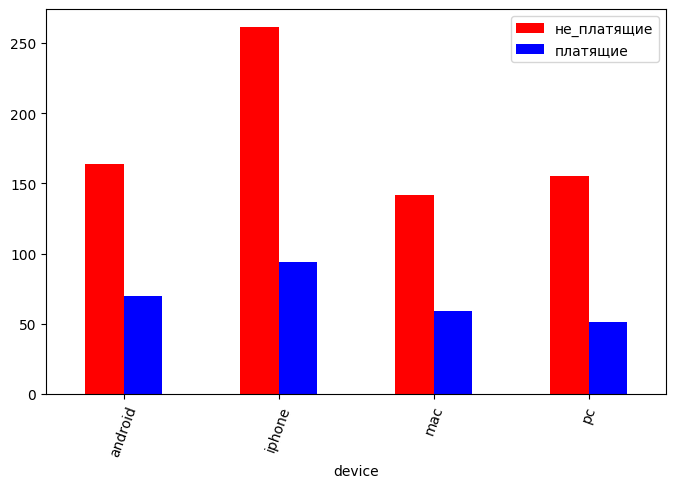

In [755]:
df_counts_device = df.groupby(['device', 'payer']).size().unstack(fill_value=0)
display(df_counts_device)

df_counts_device.plot(
    kind='bar',
    stacked=False,
    figsize=(8, 5),
    color=['red', 'blue']
  )
plt.xticks(rotation=70)
plt.legend(['не_платящие', 'платящие'])
plt.show()

## 6. Количество пользователей с разбивкой на платящих/не платящих по источникам:

payer,0,1
channel,,
email-рассылки,17,6
organic,259,87
контекстная реклама,117,42
реклама у блогеров,71,29
социальные сети,258,110


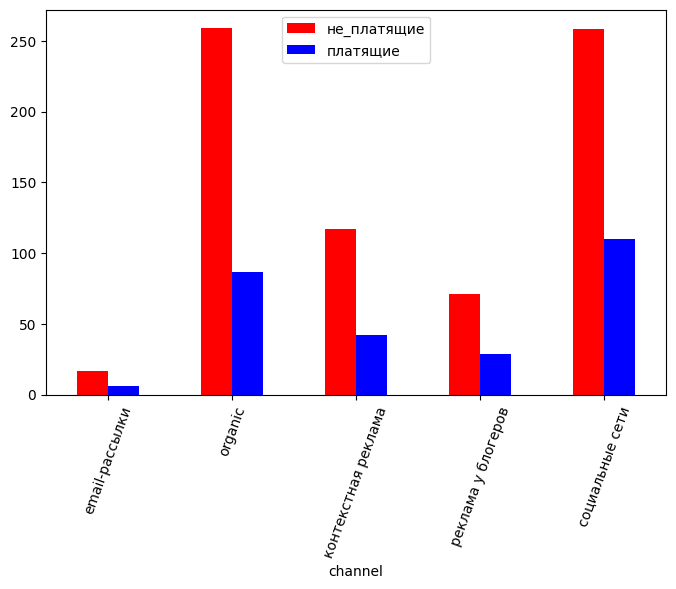

In [756]:
df_counts_channel = df.groupby(['channel', 'payer']).size().unstack(fill_value=0)
display(df_counts_channel)

df_counts_channel.plot(
    kind='bar',
    stacked=False,
    figsize=(8, 5),
    color=['red', 'blue']
  )
plt.xticks(rotation=70)
plt.legend(['не_платящие', 'платящие'])
plt.show()

 ## График показывающий есть ли сезонность в продажах `по месяцам`

,month,share
0,5,0.114660
1,6,0.178401
2,7,0.152402
3,8,0.252883
4,9,0.134211
5,10,0.167442


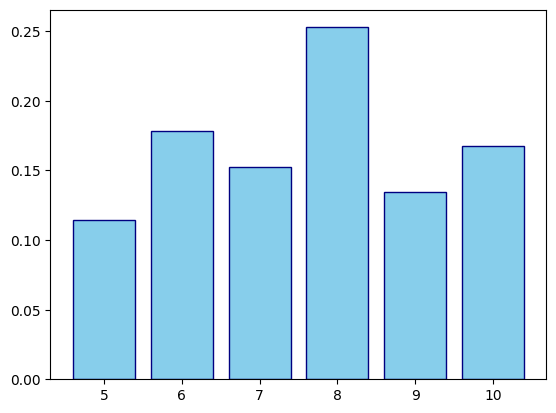

In [757]:
df_season_month = df.groupby('month')['final_revenue'].sum()
df_season_month = df_season_month / df_season_month.sum()

df_season_month = df_season_month.reset_index()
df_season_month.columns = ['month', 'share']
display(df_season_month)
labels = df_season_month['month']

plt.bar(labels, df_season_month['share'], color='skyblue', edgecolor='navy')
plt.show()


## Сезонность присутствует, видно что больше всего покупок совершается в  месяц, то есть `апрель`

## График, показывающий есть ли сезонность в продажах по `дням недели`




,day,share
0,1,0.139511
1,2,0.150899
2,3,0.144095
3,4,0.128840
4,5,0.160926
5,6,0.151543
6,7,0.124185


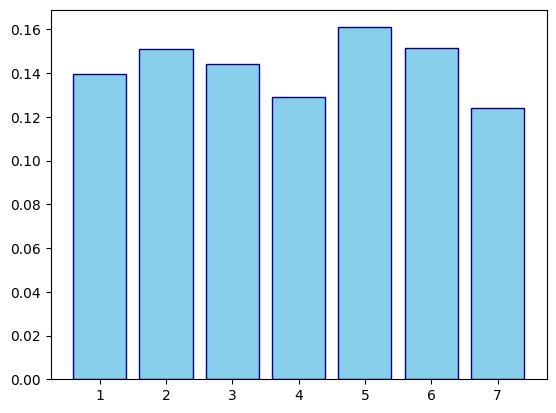

In [758]:
df_season_day = df.groupby('day')['final_revenue'].sum()
df_season_day = df_season_day / df_season_day.sum()

df_season_day = df_season_day.reset_index()
df_season_day.columns = ['day', 'share']
display(df_season_day)
labels = df_season_day['day']

plt.bar(labels, df_season_day['share'], color='skyblue', edgecolor='navy')
plt.show()


## Сезонность отвутствует, в каждый день совершается примерно равное число покупок

## График, показывающий есть ли сезонность в продажах по `времени дня`

,time,share
0,day,0.257037
1,evening,0.205973
2,morning,0.198882
3,night,0.338108


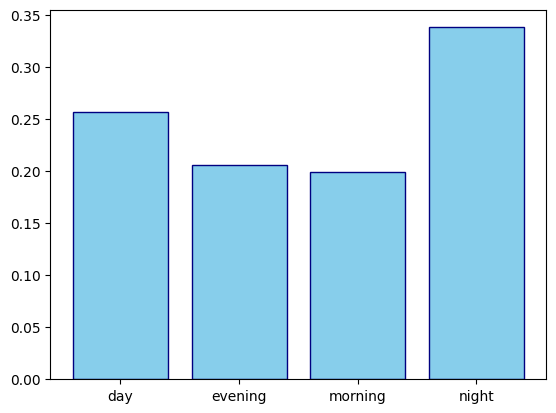

In [759]:
df_season_time = df.groupby('time_of_day')['final_revenue'].sum()
df_season_time = df_season_time / df_season_time.sum()

df_season_time = df_season_time.reset_index()
df_season_time.columns = ['time', 'share']
display(df_season_time)
labels = df_season_time['time']

plt.bar(labels, df_season_time['share'], color='skyblue', edgecolor='navy')
plt.show()


## Больше всего покупок совершается ночью (22:00 - 05:59), в остальном сезонности нет

# Диаграмма, показывающая количество покупок по типу оплаты

,payment_type,count
0,cash,59
1,credit card,33
2,debit card,34
3,e-wallet,64
4,mobile payments,84


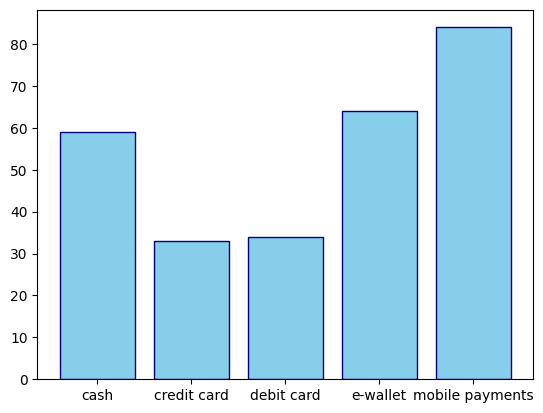

In [760]:
df_payment_type = df.groupby('payment_type').size().reset_index(name='count')
display(df_payment_type)
labels = df_payment_type['payment_type']
plt.bar(labels, df_payment_type['count'], color='skyblue', edgecolor='navy')
plt.show()


## Большинство покупок оплачивают с помощью `мобильных телефонов`. Чуть меньше, но почти одинаковое количество совершают при помощи `электронных кошельков` и `наличных`. Меньше всего оплачивают `крединными` и `дебетовыми картами`.

# Краткий итог:


*  Больше всего продаж совершается в США

*   Самый популярный рекламный канал по продажам - социальные сети

*   Самое популярное устройство, с которого совершаются покупки - iphone

*   В США неплатящих пользователей примерно в 2 раза больше, чем платящих. В остальных регионах кол-во платящих и неплатящиъ пользователей почти одинаковое
*   Кол-во платящих и неплатящих пользователей примерно одинаковое у социальных сетей и organic-канала, меньше всего у email-рассылок


*   Сезонность в продажах присутствует по месяцам (в апреле больше всего) и по времени суток (ночью больше всего)


*   Больше всего покупок оплачивается с мобильных телефонов





# Проведение расчетов

## 1) Средний чек

## Будем рассчитывать его по 3-м метрикам:
###*   AOV (Average Order Value) - показывает среднюю сумму одной покупки.
> ***AOV = выручка / количество заказов***
---
###*   ARPU (Average Revenue Per User) - показывает средний доход на одного пользователя (включая тех, кто ничего не приобретал и не платит).
>***ARPU = выручка / общее кол-во пользователей***
---
###*   ARPPU (Average Revenue Per Paying User) - показывает, сколько в среднем приносит один клиент, совершивший покупки (учитывает, что один человек мог сделать несколько заказов).
>***ARPPU = выручка / количество платящих клиентов***












In [761]:
AOV = df[df['final_revenue'] > 0]['final_revenue'].mean()
ARPPU =  df[df['final_revenue'] > 0].groupby('user_id')['final_revenue'].sum().mean()
ARPU = df['final_revenue'].sum() / df['user_id'].nunique()
dictt = {"AOV": [AOV], "ARPU": [ARPU], "ARPPU": [ARPPU]}
df_metrics = pd.DataFrame(dictt)
print(round(df_metrics.T))

            0
AOV    5095.0
ARPU   1402.0
ARPPU  5095.0


### Видим, что AOV = ARPPU. Это может быть в том случае, если каждый пользователь совершил только одну покупку, проверим это:

In [762]:
df['user_id'].value_counts().max()

1

### Максимальное количество покупок по каждому пользователю - 1, значит каждый (из платящих) совершил только одну покупку

## AOV и ARPPU значительно больше, чем ARPU. Это значит, что доля платящих пользователей значительно меньше, чем неплатящих.   

---



In [763]:
df['payer'].value_counts()

,count
payer,
0,722
1,274


## 2) Сколько покупок в среднем совершает 1 пользователь?

> Рассчитаем метрику APC (Average Payment Count) = кол-во заказов / кол-во уникальных пользователей



In [764]:
APC = len(df[df['payer'] == 1]) / len(df)
print(round(APC * 100))

28


## 3) Средняя продолжительность сессии по рекламным каналам

In [765]:
df_chan_time = df.groupby('channel')['session_duration_sec'].mean().round()
df_chan_time = df_chan_time.reset_index()
df_chan_time.columns = ['channel', 'session_duration_sec']

df_chan_time

,channel,session_duration_sec
0,email-рассылки,1400.0
1,organic,1444.0
2,контекстная реклама,1640.0
3,реклама у блогеров,1528.0
4,социальные сети,1454.0


### Значения довольно близкие, больше всего у контекстной рекламы

## 3) Средняя продолжительность сессии по типу устройства

In [766]:
df_device_time = df.groupby('device')['session_duration_sec'].mean().round()
df_device_time = df_device_time.reset_index()
df_device_time.columns = ['channel', 'session_duration_sec']

df_device_time

,channel,session_duration_sec
0,android,1476.0
1,iphone,1497.0
2,mac,1470.0
3,pc,1496.0


### Значения получились очень близкие

###4) Топ-3 рекламных канала по среднему чеку.


In [767]:
df_top_3_channel = df.groupby('channel')['final_revenue'].mean().round()
df_top_3_channel = df_top_3_channel.reset_index()
df_top_3_channel.columns = ['channel', 'final_revenue']

df_top_3_channel.nlargest(3, 'final_revenue')

,channel,final_revenue
0,email-рассылки,5332.0
3,реклама у блогеров,5216.0
4,социальные сети,5098.0


### 5) Топ-3 региона по среднему чеку.


In [768]:
df_top_3_region = df.groupby('region')['final_revenue'].mean().round()
df_top_3_region = df_top_3_region.reset_index()
df_top_3_region.columns = ['region', 'final_revenue']

df_top_3_region.nlargest(3, 'final_revenue')

,region,final_revenue
0,france,5215.0
2,uk,5212.0
1,germany,5137.0


### 6) Топ-3 месяца по среднему чеку с разбивкой по регионам.


In [769]:
df_month_region = df.groupby(['region', 'month'])['final_revenue'].mean().reset_index().round()
top_3_region = df_month_region.sort_values(['region', 'final_revenue'], ascending=[True, False]).groupby('region').head(3)
top_3_region

,region,month,final_revenue
1,france,6,5499.0
0,france,5,5224.0
5,france,10,5166.0
7,germany,6,5679.0
10,germany,9,5249.0
8,germany,7,4999.0
12,uk,5,5499.0
17,uk,10,5342.0
13,uk,6,5270.0
21,united states,8,5163.0


## 7) Рассчет MAU (Monthly Active Users)

In [770]:
MAU = df.groupby(['month', 'channel'])['user_id'].nunique().reset_index(name='mau')
top_3_MAU = MAU.sort_values(['month', 'mau'], ascending=[True, False]).groupby('month').head(3)
top_3_MAU

,month,channel,mau
1,5,organic,76
4,5,социальные сети,41
3,5,реклама у блогеров,14
6,6,organic,59
9,6,социальные сети,52
7,6,контекстная реклама,28
14,7,социальные сети,56
11,7,organic,46
12,7,контекстная реклама,24
19,8,социальные сети,68


## Создание таблицы в которой будет указано по рекламным каналам: количество пользователей, количество уникальных пользователей, количество платящих пользователей, сумма продаж.

In [771]:
new_df = df.groupby('channel').agg({
    'user_id': ['count', 'nunique'],
    'payer': 'sum',
    'final_revenue': 'sum'
}).reset_index().round()

new_df.columns = ['channel', 'count_users', 'unique_users', 'paying_users', 'total_revenue']
new_df

,channel,count_users,unique_users,paying_users,total_revenue
0,email-рассылки,23,23,6,31994.0
1,organic,346,346,87,441316.0
2,контекстная реклама,159,159,42,210660.0
3,реклама у блогеров,100,100,29,151271.0
4,социальные сети,368,368,110,560793.0


 ### Какой источник “принес” больше всего платящих пользователей и большую сумму продаж.


In [772]:
best_payer = new_df.loc[new_df['paying_users'].idxmax()]['channel']
best_revenue = new_df.loc[new_df['total_revenue'].idxmax()]['channel']

print(f'Больше всего платящих пользователей принес {best_payer}')
print(f'Большую сумму продаж принес {best_revenue}')

Больше всего платящих пользователей принес социальные сети
Большую сумму продаж принес социальные сети


## В обоих вариантах рекламный канал - `социальные сети`

# Краткий итог:


*   AOV = ARPPU = 5095.0

*   ARPU = 1402.0
*   APC = 28 %



*   Средний чек больше всего у email-рассылок, регион france


*   Создана новая таблица с данными по рекламным каналам: кол-во пользователей, сумма продаж и т.д.



---
---

# Проверка гипотез

---

# Часть 1. Визуализация данных и проверка гипотез на целесообразность

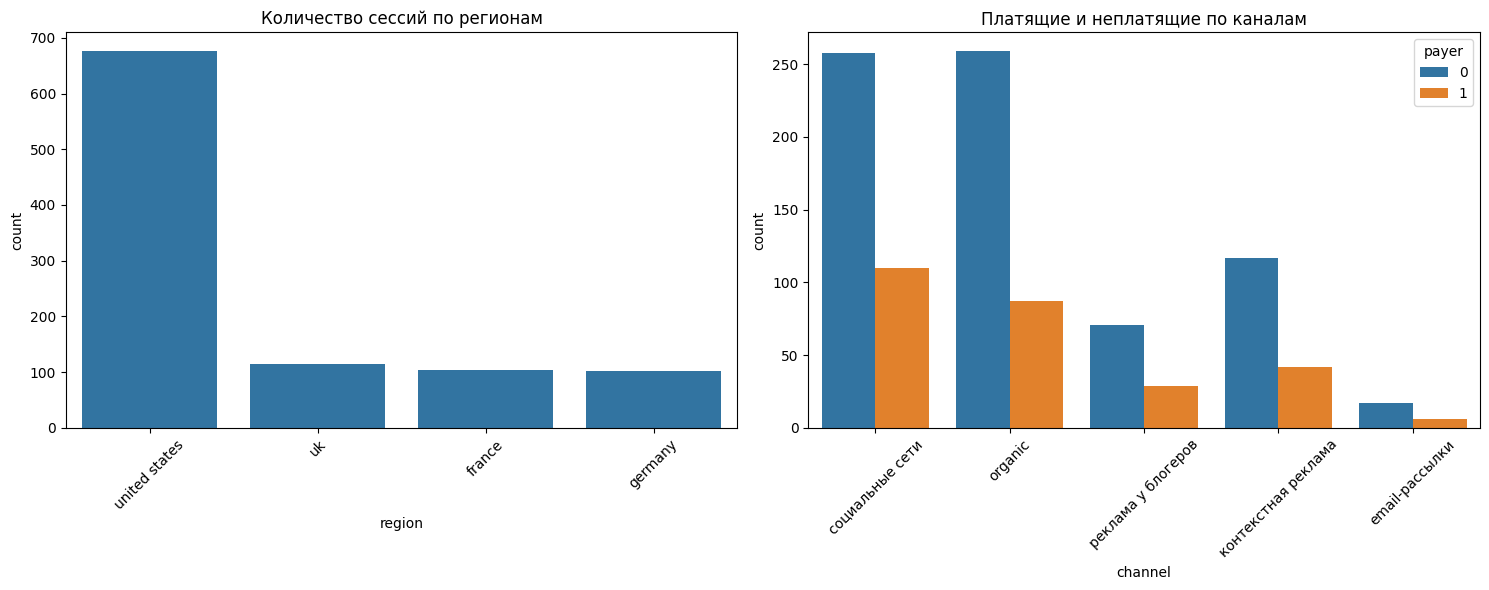

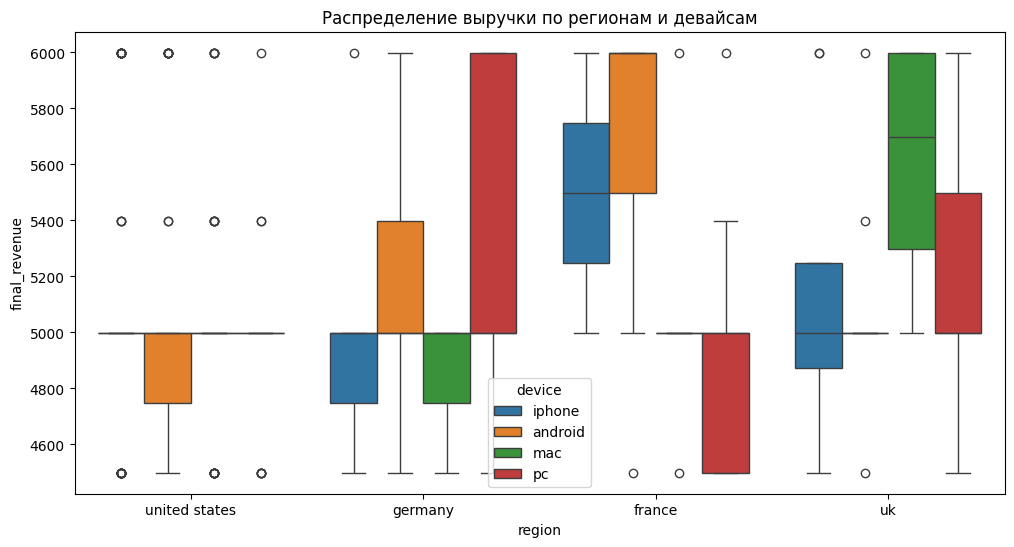

In [773]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# Количество сессий по регионам
sns.countplot(data=df, x='region', order=df['region'].value_counts().index, ax=ax[0])
ax[0].set_title('Количество сессий по регионам')
ax[0].tick_params(axis='x', rotation=45)

# Количество платящих & неплатящих по каналам
sns.countplot(data=df, x='channel', hue='payer', ax=ax[1])
ax[1].set_title('Платящие и неплатящие по каналам')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Анализ распределения выручки
payers_df = df[df['payer'] == 1]
plt.figure(figsize=(12, 6))
sns.boxplot(data=payers_df, x='region', y='final_revenue', hue='device')
plt.title('Распределение выручки по регионам и девайсам')
plt.show()


# Выводы из графиков выше:

*  Графический анализ показывает, что большая часть пользователей сосредоточены в США, поэтому выводы по другим регионам скорее всего будут статистически ненадежны

*   Распределение выручки содержит много аномальных выбросов, из-за чего для корректного анализа необходимо использовать медиану вместо среднего

*   Для получения точных ответов данные нужно сегментировать данные по регионам и не сравнивать группы с критически разным количеством наблюдений

---
---

# Часть 2. Проверка гипотез

*   Влияет ли тип устройства на количество покупок в день по каждому региону?
*   Влияет ли тип рекламного канала на количество покупок в день по каждому региону?
*   Проверить гипотезу о том, что средний чек отличается в зависимости от региона?
*   Проверить гипотезу о том, что средний чек отличается в зависимости от рекламного канала?
*   Проверить гипотезу о том, что средний чек отличается в зависимости от времени суток?
*   Есть ли взаимосвязь между продолжительностью сессии с суммой покупок?
*   Существует ли взаимосвязь между типом устройства и способом оплаты?
*   Существует ли связь между регионом и способом оплаты?
---

#Сравнение среднего чека:

*   Отличается ли средний чек в зависимости от региона?
*   Отличается ли средний чек в зависимости от рекламного канала?
*   Отличается ли средний чек в зависимости от времени суток?

Так как групп для сравнения больше двух в каждой из гипотез, нужно использовать критерий Краскела-Уоллиса

In [774]:
payers = df[df['payer'] == 1]
def aov_hypothesis(dataframe, category_col):
    groups = [group['final_revenue'].values for name, group in dataframe.groupby(category_col)]
    stat, p_value = st.kruskal(*groups)
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Отвергаем H0, средний чек значительно отличается в зависимости от категории\n")
    else:
        print("Не удалось отвергнуть H0, значимых отличий в среднем чеке нет\n")

### Отличается ли средний чек в зависимости от региона?

In [775]:
aov_hypothesis(payers, 'region')

p-value: 0.2827
Не удалось отвергнуть H0, значимых отличий в среднем чеке нет



### Вывод: средний чек не зависит от региона

---

### Отличается ли средний чек в зависимости от рекламного канала?

In [776]:
aov_hypothesis(payers, 'channel')

p-value: 0.2816
Не удалось отвергнуть H0, значимых отличий в среднем чеке нет



### Вывод: средний чек не зависит от рекламного канала

---

### Отличается ли средний чек в зависимости от времени суток?

In [777]:
aov_hypothesis(payers, 'time_of_day')

p-value: 0.4233
Не удалось отвергнуть H0, значимых отличий в среднем чеке нет



### Вывод: средний чек не зависит от времени суток

---
---
#Сравнение количества покупок в день:

*   Влияет ли тип устройства на количество покупок в день по каждому региону?
*   Влияет ли тип рекламного канала на количество покупок в день по каждому
региону?

Здесь сначала нужно сгруппировать данные по дням. Затем можно использовать тест Краскела-Уоллиса для сравнения этих ежедневных показателей

In [778]:
def daily_purchases_hypothesis(df, region, category_col):
    region_data = df[(df['region'] == region) & (df['payer'] == 1)]
    daily_counts = region_data.groupby(['session_date', category_col])['user_id'].count().reset_index()
    daily_counts.rename(columns={'user_id': 'purchases'}, inplace=True)
    groups = [group['purchases'].values for name, group in daily_counts.groupby(category_col)]
    if len(groups) < 2 or any(len(g) < 5 for g in groups):
        print(f"Недостаточно данных по дням в регионе {region}")
        return
    stat, p_value = stats.kruskal(*groups)
    print(f"Регион: {region}, p-value: {p_value:.4f}")
    if p_value < 0.05:
         print(f"Отвергаем H0, влияние есть")
    else:
         print("Не удалось отвергнуть H0, значимого влияния не обнаружено")

### Влияет ли тип устройства на количество покупок в день по каждому региону?


In [779]:
for r in df['region'].dropna().unique():
    daily_purchases_hypothesis(df, r, 'device')

Регион: united states, p-value: 0.4040
Не удалось отвергнуть H0, значимого влияния не обнаружено
Недостаточно данных по дням в регионе france
Недостаточно данных по дням в регионе germany
Недостаточно данных по дням в регионе uk


### Вывод: по всем регионам невозможно посчитать из-за малого количества данных, но в USA можно сказать, что значимого влияния не обнаружено

---

### Влияет ли тип рекламного канала на количество покупок в день по каждому региону?

In [780]:
for r in df['region'].dropna().unique():
    daily_purchases_hypothesis(df, r, 'channel')

Регион: united states, p-value: 0.1060
Не удалось отвергнуть H0, значимого влияния не обнаружено
Недостаточно данных по дням в регионе france
Недостаточно данных по дням в регионе germany
Недостаточно данных по дням в регионе uk


### Вывод: по всем регионам невозможно посчитать из-за малого количества данных, но в USA можно сказать, что значимого влияния не обнаружено
---
---

# Взаимосвязь числовых признаков

*  Есть ли взаимосвязь между продолжительностью сессии с суммой покупок?

Обычная корреляция Пирсона здесь не справится из-за сильных выбросов (видно по графику в сумме покупок). Нужно использовать корреляцию Спирмена

In [781]:
duration = payers['session_duration_sec']
revenue = payers['final_revenue']
print(f'p-value duration: {st.shapiro(duration)[1]:.4f}, p-value revenue: {st.shapiro(revenue)[1]:.4f}')
correlation, p_value = stats.spearmanr(duration, revenue)
print(f"Коэффициент корреляции Спирмена: {correlation:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    if correlation > 0:
        print("Есть значимая положительная связь: чем дольше сессия, тем выше чек")
    elif correlation < 0:
        print("Есть значимая отрицательная связь. Долгие сессии приводят к мелким чекам")
else:
    print("Статистически значимой связи между временем на сайте и суммой покупки нет")

p-value duration: 0.0000, p-value revenue: 0.0000
Коэффициент корреляции Спирмена: 0.005
p-value: 0.9295
Статистически значимой связи между временем на сайте и суммой покупки нет


### Вывод: взаимосвязи между продолжительностью сессии с суммой покупок нет

---

# Взаимосвязь категориальных признаков

*   Существует ли взаимосвязь между типом устройства и способом оплаты?
*   Существует ли связь между регионом и способом оплаты?

Для анализа связи между двумя категориальными признаками используется Критерий независимости Хи-квадрат

In [782]:
def categorical_hypothesis(df, col1, col2):
    data = df[[col1, col2]].dropna()
    contingency_table = pd.crosstab(data[col1], data[col2])
    chi2, p_value, _, _ = st.chi2_contingency(contingency_table)
    print(f"p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Связь существует\n")
    else:
        print(f"Связи нет, выбор способа оплаты случаен\n")

payers_only = df[df['payer'] == 1]

### Существует ли взаимосвязь между типом устройства и способом оплаты?

In [783]:
categorical_hypothesis(payers_only, 'device', 'payment_type')

p-value: 0.0104
Связь существует



### Вывод: связь между типом устройства и способом оплаты существует
---

### Существует ли связь между регионом и способом оплаты?

In [784]:
categorical_hypothesis(payers_only, 'region', 'payment_type')

p-value: 0.9798
Связи нет, выбор способа оплаты случаен



### Вывод: связи между регионом и способом оплаты нет
---

# Выводы:

1. В других странах помимо США покупок слишком мало, поэтому любые выводы по ним могут быть статистически не значимыми

2. Канал и время дня не вллияют на чек - в среднем все тратят примерно одинаковую сумму

3. Если пользователь сидит на сайте долго, это не значит, что он купит что-то дорогое - часто быстрые покупки оказываются самыми крупными

4. Техника влияет только на способ оплаты, но сумма заказа от этого не меняется

---
---

# Регрессионное моделирование

#### Импорт библиотек

In [785]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [786]:
df.head()

,user_id,region,device,channel,session_start,session_end,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,payer,session_duration_sec,final_revenue,time_of_day
0,529697267522,united states,iphone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,2025-05-01,5,3,0,2025-05-01 00:06:40,4999.0,mobile payments,0.0,1,26.0,4999.0,night
1,601292388085,united states,pc,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,0,782.0,NaN,morning
2,852898876338,united states,mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,2025-05-01,5,3,4,NaT,NaN,NaN,NaN,0,251.0,NaN,night
3,998513020664,united states,iphone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,2025-05-01,5,3,18,NaT,NaN,NaN,NaN,0,233.0,NaN,evening
4,240702200943,united states,mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,2025-05-02,5,4,14,NaT,NaN,NaN,NaN,0,319.0,NaN,day


### Будем строить линейную модель, основываясь на признаках: `продолжительность сессии`, `рекламный канал`, `тип устройства`, `время дня`, `месяц`, `промокод`, `выручка`

In [787]:
# Копируем датасет c платящими людьми
df_model = df[df['payer'] == 1].copy()

### Удаляем все строки, где еть NaN

In [788]:
cols = ['final_revenue',  'session_duration_sec', 'month', 'hour_of_day', 'promo_code', 'channel', 'device']
df_model = df_model[cols].dropna()

### Кодирование категориальных признаков

In [789]:
df_model = pd.get_dummies(df_model, columns=['channel', 'device'], drop_first=True)
df_model.head().T

,0,20,28,33,34
final_revenue,4999.0,4999.0,4499.1,4499.1,4999.0
session_duration_sec,26.0,240.0,4177.0,47.0,306.0
month,5,5,5,5,5
hour_of_day,0,15,13,16,9
promo_code,0.0,0.0,1.0,1.0,0.0
channel_organic,False,True,True,True,False
channel_контекстная реклама,False,False,False,False,False
channel_реклама у блогеров,False,False,False,False,False
channel_социальные сети,True,False,False,False,True
device_iphone,True,False,False,False,False


### Выделяем X и y

In [790]:
X = df_model.drop(columns=['final_revenue'])
y = df_model['final_revenue']

### Разделяем на тестовую и тренировочную выборки

In [791]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Создаем модель

In [792]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Основные метрики модели

In [793]:
y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")

MAE: 385.0896081338635
R2: 0.22524759995387056
